# Project: Customer Churn Prediction

This project aimed to build a machine learning classification model to predict customer churn using the Customer Churn Prediction dataset from Kaggle. The project followed a structured data science methodology covering data assessment, exploratory data analysis, preprocessing, feature engineering, model training, hyperparameter tuning, and evaluation.

## Phase 1 Data Collection

data was collected in kaggle: https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset/data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Phase 2 Initial Data Assessment

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [4]:
training_path = '/content/drive/MyDrive/KaggleDatasets/CustomerChurn/1/customer_churn_dataset-training-master.csv'
testing_path = '/content/drive/MyDrive/KaggleDatasets/CustomerChurn/1/customer_churn_dataset-testing-master.csv'

In [5]:
train = pd.read_csv(training_path)
test = pd.read_csv(testing_path)

In [ ]:
# checking the number of records and columns
print(f"training has {train.shape[0]} rows and {train.shape[1]} columns")
print(f"testing has {test.shape[0]} rows and {test.shape[1]} columns")

training has 440833 rows and 12 columns
testing has 64374 rows and 12 columns


In [6]:
train.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [7]:
# checking for training class imbalance
print(train['Churn'].value_counts(normalize=True) * 100)

Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Training Churn Class Distribution')

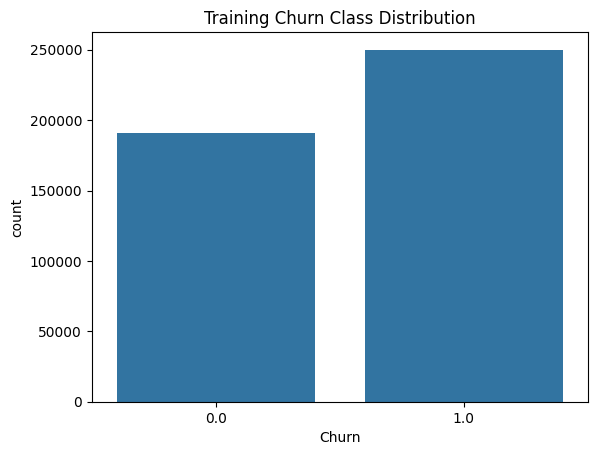

In [8]:
sns.countplot(x='Churn', data=train)
plt.title('Training Churn Class Distribution')

In [9]:
print(test['Churn'].value_counts(normalize=True) * 100)

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Training Churn Class Distribution')

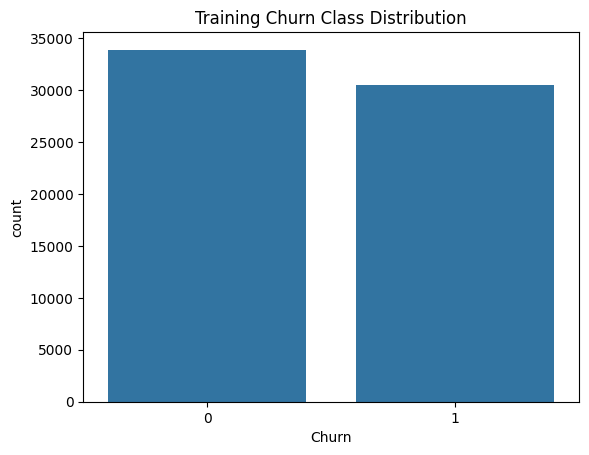

In [10]:
sns.countplot(x='Churn', data=test)
plt.title('Training Churn Class Distribution')

In [11]:
# check the number of missing values
train.isna().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [12]:
train.dropna(inplace=True)
test.dropna(inplace=True)

In [13]:
test.isna().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [14]:
# checking for duplicate records
print(f"number of duplicates in training: {train.duplicated().sum()}")
print(f"number of duplicates in testing: {test.duplicated().sum()}")

number of duplicates in training: 0
number of duplicates in testing: 0


In [15]:
train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 43.7+ MB


In [17]:
columns_change_to_int = ['CustomerID','Tenure','Age','Usage Frequency','Support Calls','Payment Delay','Last Interaction','Churn']
train[columns_change_to_int] = train[columns_change_to_int].astype(int)
columns_change_to_categorical = ['Gender','Subscription Type','Contract Length']
train[columns_change_to_categorical] = train[columns_change_to_categorical].astype('category')

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   CustomerID         440832 non-null  int64   
 1   Age                440832 non-null  int64   
 2   Gender             440832 non-null  category
 3   Tenure             440832 non-null  int64   
 4   Usage Frequency    440832 non-null  int64   
 5   Support Calls      440832 non-null  int64   
 6   Payment Delay      440832 non-null  int64   
 7   Subscription Type  440832 non-null  category
 8   Contract Length    440832 non-null  category
 9   Total Spend        440832 non-null  float64 
 10  Last Interaction   440832 non-null  int64   
 11  Churn              440832 non-null  int64   
dtypes: category(3), float64(1), int64(8)
memory usage: 34.9 MB


In [19]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [20]:
test['Total Spend'] = test['Total Spend'].astype(float)
test['Churn'] = test['Churn'].astype(int)
columns_change_to_categorical = ['Gender','Subscription Type','Contract Length']
test[columns_change_to_categorical] = test[columns_change_to_categorical].astype('category')

## Phase 3: Exploratory Data Analysis and Data Cleaning

In [21]:
train.drop('CustomerID', axis=1, inplace=True)
test.drop('CustomerID', axis=1, inplace=True)

In [22]:
train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


In [23]:
test.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598.0,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584.0,20,0
2,47,Male,27,10,2,29,Premium,Annual,757.0,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232.0,18,0
4,53,Female,58,24,9,2,Standard,Annual,533.0,18,0


In [24]:
from scipy import stats
from scipy.stats import pointbiserialr

def cramers_v(x, y):
    ''' function to see tha association between two categorical data'''
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

def eta_squared(numeric_col, cat_col):
    ''' function to see the association between numeric column and categorical column with 2+ categories'''
    groups = [numeric_col[cat_col == c] for c in cat_col.unique()]
    return stats.f_oneway(*groups)[0]  # F-statistic as proxy

def association_matrix(df, num_cols, cat_cols):
    ''' function to see the association between all column of the dataset, used to check for multi colinearity'''
    all_cols = num_cols + cat_cols
    matrix = pd.DataFrame(np.ones((len(all_cols), len(all_cols))),
                          index=all_cols, columns=all_cols)
    for i, c1 in enumerate(all_cols):
        for j, c2 in enumerate(all_cols):
            if i == j:
                matrix.loc[c1, c2] = 1.0
            elif c1 in num_cols and c2 in num_cols:
                matrix.loc[c1, c2] = df[c1].corr(df[c2], method='spearman')
            elif c1 in cat_cols and c2 in cat_cols:
                matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])
            else:
                num = c1 if c1 in num_cols else c2
                cat = c1 if c1 in cat_cols else c2
                corr, _ = pointbiserialr(df[num], pd.factorize(df[cat])[0])
                matrix.loc[c1, c2] = abs(corr)
    return matrix

In [ ]:
# checking the association of the feature columns to the target column
num_cols = ['Tenure', 'Age', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Last Interaction', 'Total Spend']
cat_cols = ['Gender', 'Subscription Type', 'Contract Length', 'Churn']

for col in num_cols:
    # since we are comparing numerical column to the target (which is churn that is a categorical column with 2 categories) we will use point biserialr to know its correlation
    corr, pval = pointbiserialr(train[col], train['Churn'])
    print(f"{col}: r={corr:.3f}, p={pval:.4f}")

for col in cat_cols:
    # since we have categorical columns in the dataset we will call the function the cremers to know the association
    print(f"{col}: V={cramers_v(train[col], train['Churn']):.3f}")

Tenure: r=-0.052, p=0.0000
Age: r=0.218, p=0.0000
Usage Frequency: r=-0.046, p=0.0000
Support Calls: r=0.574, p=0.0000
Payment Delay: r=0.312, p=0.0000
Last Interaction: r=0.150, p=0.0000
Total Spend: r=-0.429, p=0.0000
Gender: V=0.175
Subscription Type: V=0.021
Contract Length: V=0.434
Churn: V=1.000


after checking the associations of the targets we concluded that we can remove Tenure, Usage Frequency, Subscription Type, Last Interaction, and Gender columns since it shows a low correlation with the target column

In [25]:
# dropping columns
train.drop(['Tenure', 'Usage Frequency', 'Subscription Type','Gender','Last Interaction'], axis=1, inplace=True)
test.drop(['Tenure', 'Usage Frequency', 'Subscription Type','Gender','Last Interaction'], axis=1, inplace=True)

In [26]:
# checking multicolinearity between feature columns
num_cols = ['Age', 'Support Calls', 'Payment Delay', 'Total Spend']
cat_cols = ['Contract Length']
association_matrix(train, num_cols, cat_cols)

,Age,Support Calls,Payment Delay,Total Spend,Contract Length
Age,1.000000,0.168617,0.051443,-0.070357,0.000334
Support Calls,0.168617,1.000000,0.146181,-0.199095,0.000458
Payment Delay,0.051443,0.146181,1.000000,-0.104067,0.000127
Total Spend,-0.070357,-0.199095,-0.104067,1.000000,0.000642
Contract Length,0.000334,0.000458,0.000127,0.000642,1.000000


since there are no multicolinearity we will not drop any columns now

In [80]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   Age              440832 non-null  int64   
 1   Support Calls    440832 non-null  int64   
 2   Payment Delay    440832 non-null  int64   
 3   Contract Length  440832 non-null  category
 4   Total Spend      440832 non-null  float64 
 5   Churn            440832 non-null  int64   
dtypes: category(1), float64(1), int64(4)
memory usage: 20.6 MB


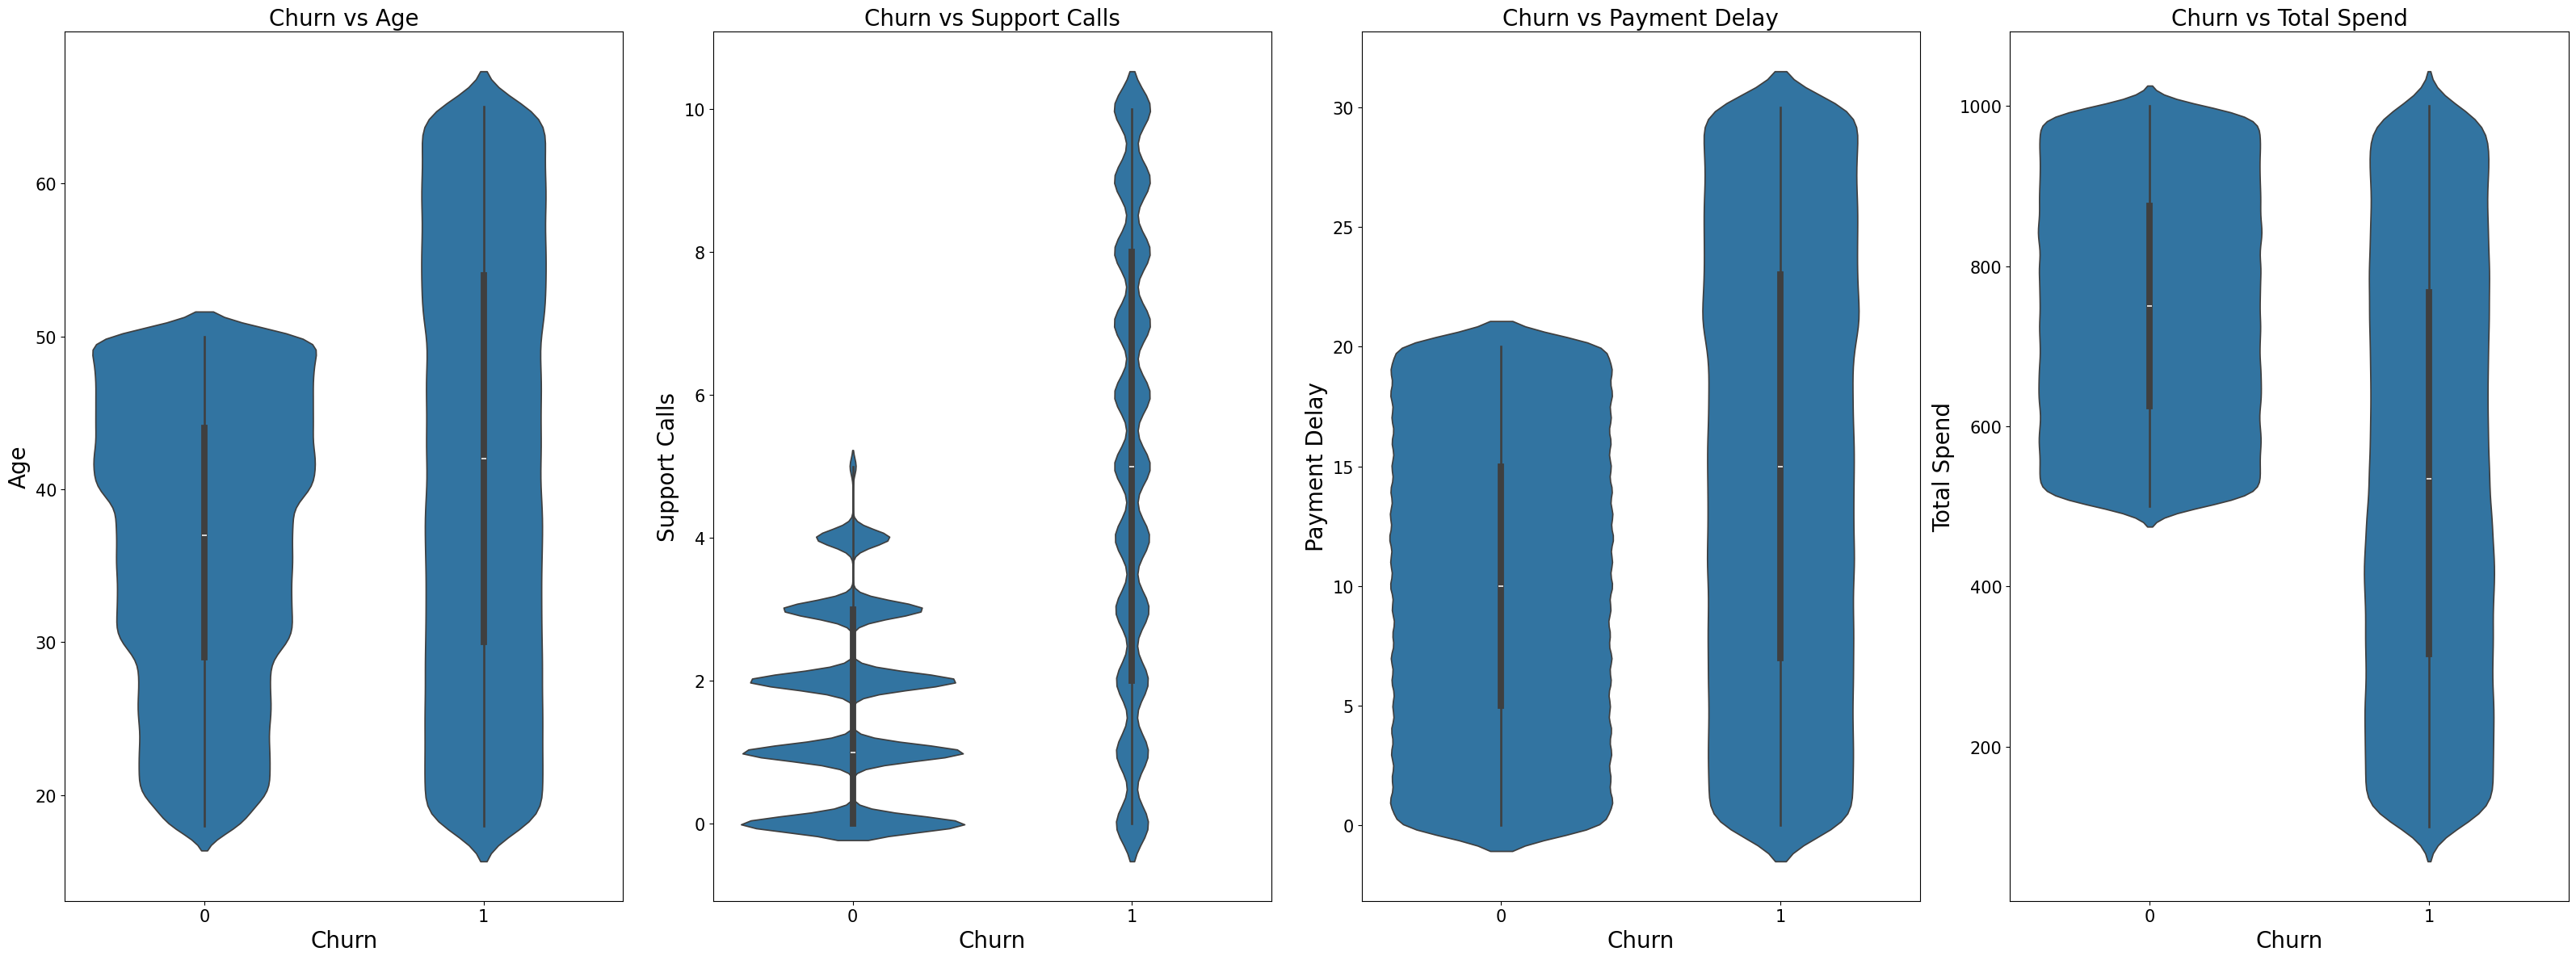

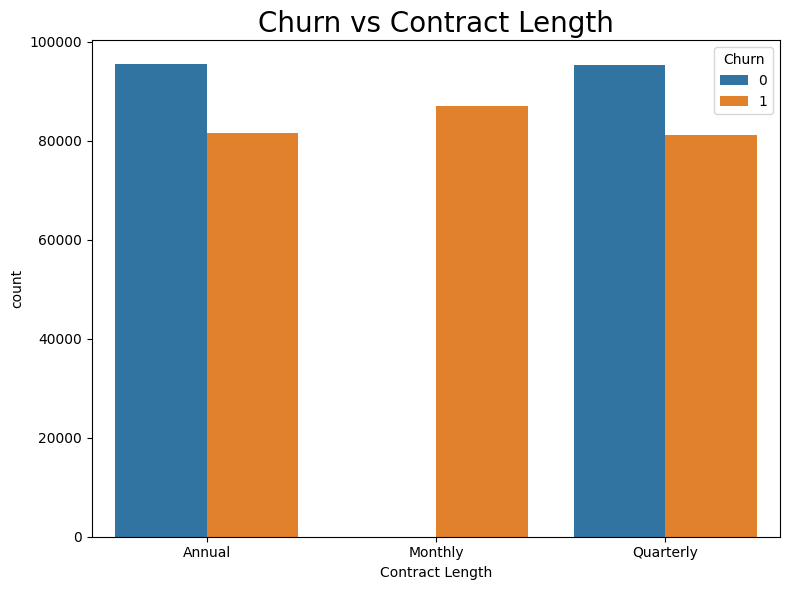

In [29]:
# checking the distributions of every feature column with respect to the target feature
num_features = ['Age', 'Support Calls', 'Payment Delay', 'Total Spend']
cat_features = ['Contract Length']

# violin plots for numeric features
fig, axes = plt.subplots(1, len(num_features), figsize=(32, 12))
for i, feature in enumerate(num_features):
    sns.violinplot(data=train, x='Churn', y=feature, ax=axes[i])
    axes[i].set_title(f'Churn vs {feature}', fontsize=20)
    axes[i].set_xlabel('Churn', fontsize=20)
    axes[i].set_ylabel(feature, fontsize=20)
    axes[i].tick_params(axis='both', labelsize=15)
plt.tight_layout()

# countplot for Contract Length
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=train, x='Contract Length', hue='Churn', ax=ax)
ax.set_title('Churn vs Contract Length', fontsize=20)
plt.tight_layout()

analysis: </br>
Churn vs Age: Older customers churn slightly more </br>
Churn vs Support Calls: customer with 5 or more support calls are more likely to churn  </br>
Churn vs Payment Delay: customer with 20 or more payment delays are more likely to churn </br>
Churn vs Total Spend: customer who spend more (500 above are not likely to churn) </br>
Churn vs Contract Length: customer  who paid monthly are more likely to churn </br>

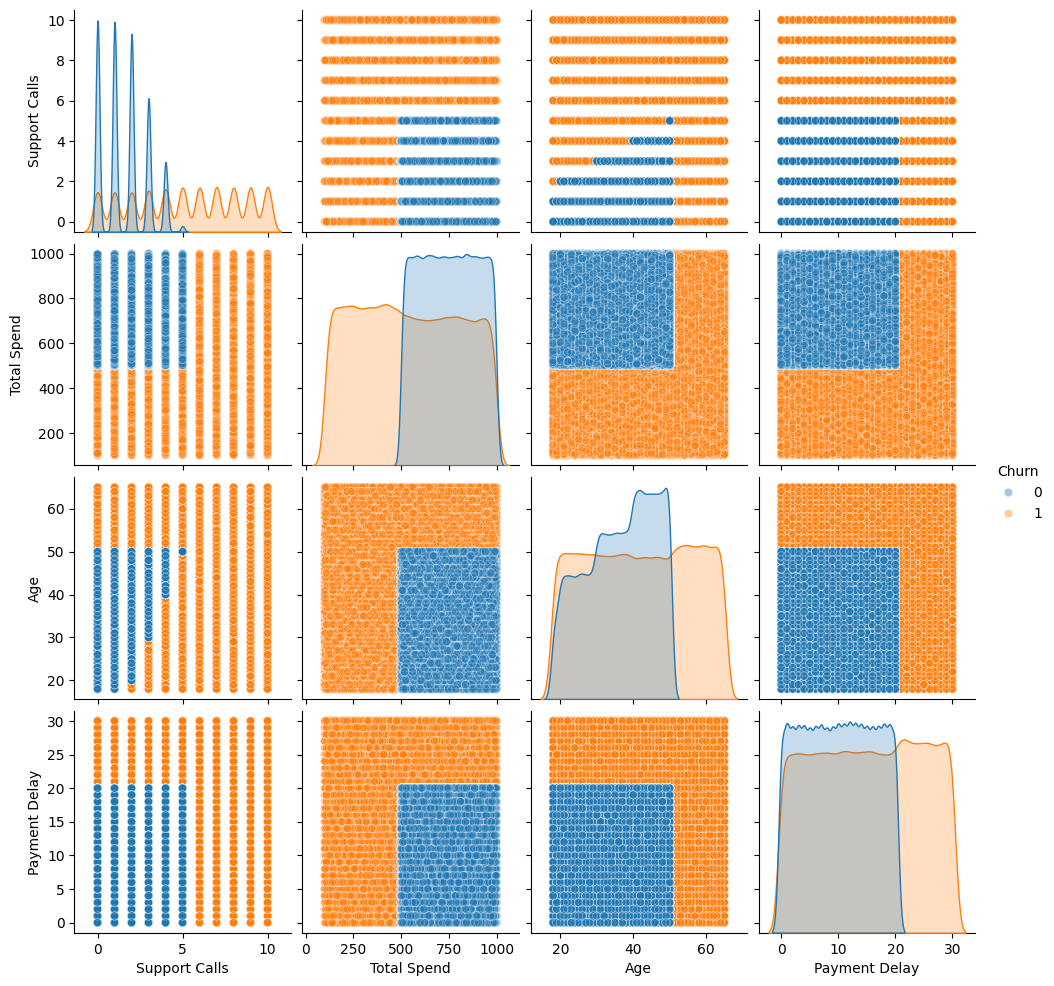

In [ ]:
sns.pairplot(
    train[num_cols + ['Churn']],
    hue='Churn',
    plot_kws={'alpha': 0.4},
    diag_kind='kde'
)

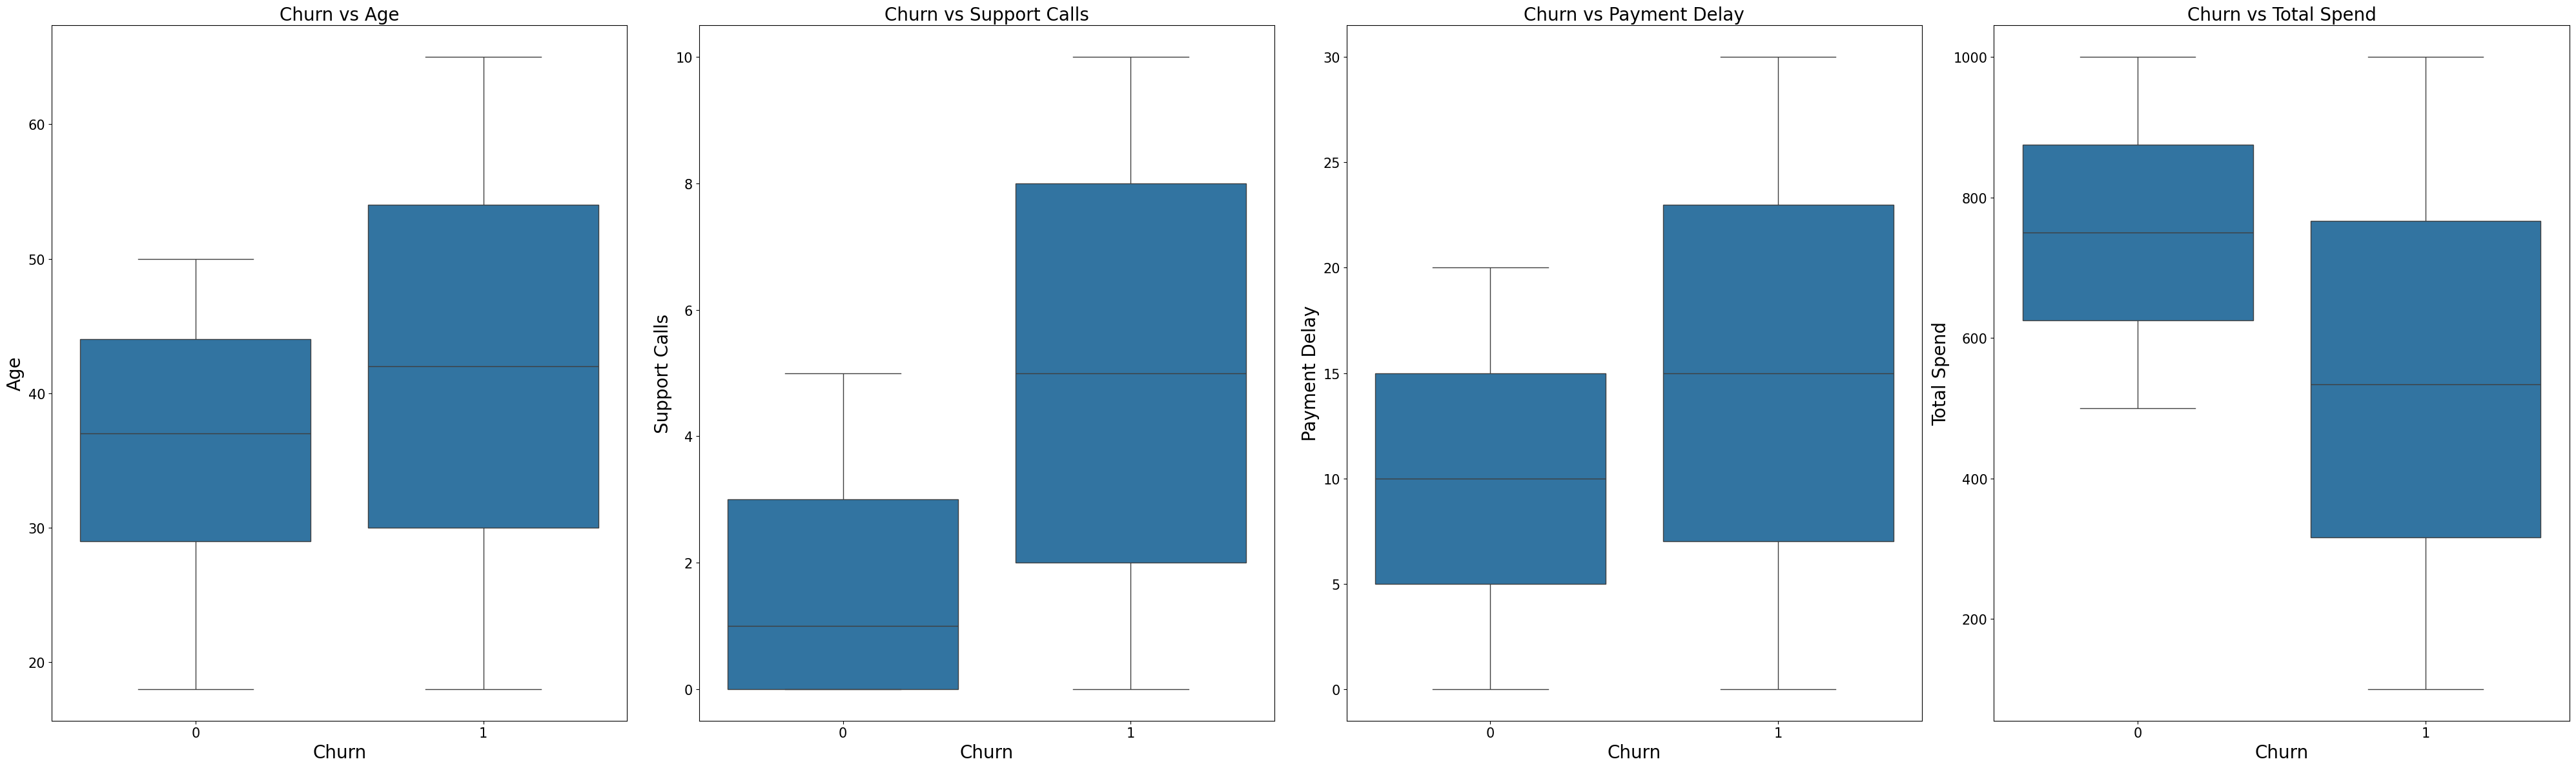

In [30]:
# checking for outliers
fig, axes = plt.subplots(1,len(num_features),figsize=(40,12))

for i,feature in enumerate(num_features):
  sns.boxplot(data=train, x='Churn', y=feature, ax=axes[i])
  axes[i].set_title(f'Churn vs {feature}',fontsize=20)
  axes[i].set_xlabel('Churn',fontsize=20)
  axes[i].set_ylabel(feature,fontsize=20)
  axes[i].tick_params(axis='both',labelsize=15)

plt.tight_layout()

## Phase 4: Data Preprocessing

In [ ]:
df = pd.concat([train,test], ignore_index=True)

In [ ]:
df.shape

(505206, 6)

### Handling Outliers

looking on the boxplot earlier, it shows no outlier indicator so we'll skip the process for cleaning the outliers

### Encoding Categorical Columsn

In [ ]:
# encoding categorical variables
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Monthly','Quarterly','Annual']])
df[['Contract Length']] = oe.fit_transform(df[['Contract Length']])

In [ ]:
#checking
df.head()

,Age,Support Calls,Payment Delay,Contract Length,Total Spend,Churn
0,30,5,18,2.0,932.0,1
1,65,10,8,0.0,557.0,1
2,55,6,18,1.0,185.0,1
3,58,7,7,0.0,396.0,1
4,23,5,8,0.0,617.0,1


In [ ]:
# checking for correct dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505206 entries, 0 to 505205
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Age              505206 non-null  int64  
 1   Support Calls    505206 non-null  int64  
 2   Payment Delay    505206 non-null  int64  
 3   Contract Length  505206 non-null  float64
 4   Total Spend      505206 non-null  float64
 5   Churn            505206 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 23.1 MB


In [ ]:
# changing the dtype of Contract Length Column
df['Contract Length'] = df['Contract Length'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505206 entries, 0 to 505205
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Age              505206 non-null  int64  
 1   Support Calls    505206 non-null  int64  
 2   Payment Delay    505206 non-null  int64  
 3   Contract Length  505206 non-null  int64  
 4   Total Spend      505206 non-null  float64
 5   Churn            505206 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 23.1 MB


### Scaling

since we are using XGBoost, LightGBM and CatBoost model, we will not need to scale our data

### Feature Engineering

In [ ]:
# feature engineering we will add columns to help more of the model we will train
# adding risk_score column by combining columns with high correlation
df['risk_score'] = df['Payment Delay'] * df['Support Calls']

# adding high caller flag  to know the model if the customer is a high caller
df['high_caller_flag'] = (df['Support Calls'] >= 4).astype(int)

# adding a low spender flag to know if the customer spends less money
df['low_spender_flag'] = (df['Total Spend'] < 500).astype(int)

In [ ]:
df.head()

,Age,Support Calls,Payment Delay,Contract Length,Total Spend,Churn,risk_score,high_caller_flag,low_spender_flag
0,30,5,18,2,932.0,1,90,1,0
1,65,10,8,0,557.0,1,80,1,0
2,55,6,18,1,185.0,1,108,1,1
3,58,7,7,0,396.0,1,49,1,1
4,23,5,8,0,617.0,1,40,1,0


In [ ]:
# move churn column to the end
churn_col = df.pop('Churn')
df['Churn'] = churn_col

In [ ]:
# checking
df.head()

,Age,Support Calls,Payment Delay,Contract Length,Total Spend,risk_score,high_caller_flag,low_spender_flag,Churn
0,30,5,18,2,932.0,90,1,0,1
1,65,10,8,0,557.0,80,1,0,1
2,55,6,18,1,185.0,108,1,1,1
3,58,7,7,0,396.0,49,1,1,1
4,23,5,8,0,617.0,40,1,0,1


## Model Training

In [ ]:
# removing the targets
X = df.drop('Churn', axis=1)
y = df['Churn']

# splitting the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

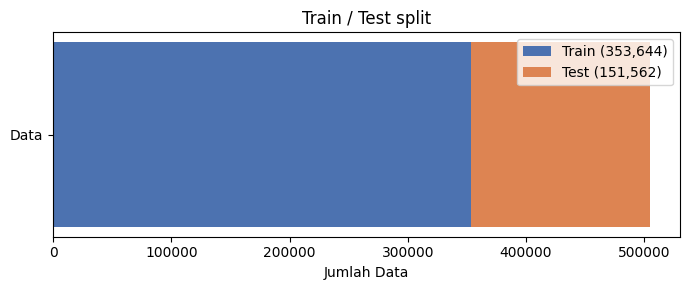

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(['Data'], [len(X_train)], color='#4C72B0', label=f'Train ({len(X_train):,})')
ax.barh(['Data'], [len(X_test)], left=[len(X_train)], color='#DD8452', label=f'Test ({len(X_test):,})')
ax.set_xlabel('Number of records')
ax.set_title('Train / Test split')
ax.legend()
plt.tight_layout()

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


### Doing Hyperparameter tuning

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.4 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 300),
        'max_depth'       : trial.suggest_int('max_depth', 2, 6),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state'    : 42,
        'eval_metric'     : 'logloss'
    }
    model = XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_test, y_test, cv=skf, scoring='accuracy')
    return scores.mean()

study_XGB = optuna.create_study(direction='maximize')
study_XGB.optimize(objective, n_trials=50)
print("Best params:", study_XGB.best_params)

[I 2026-05-30 03:04:50,151] A new study created in memory with name: no-name-16c4e235-1f56-4c24-8280-f06e5dfd4da8
[I 2026-05-30 03:05:14,568] Trial 0 finished with value: 0.9213786991474896 and parameters: {'n_estimators': 229, 'max_depth': 3, 'learning_rate': 0.0877731637298579, 'reg_alpha': 0.443247712205745, 'reg_lambda': 0.7525811152501012, 'min_child_weight': 2}. Best is trial 0 with value: 0.9213786991474896.
[I 2026-05-30 03:05:17,003] Trial 1 finished with value: 0.9211015848746966 and parameters: {'n_estimators': 70, 'max_depth': 3, 'learning_rate': 0.164802808206593, 'reg_alpha': 0.9533370198763513, 'reg_lambda': 0.19167513564933059, 'min_child_weight': 10}. Best is trial 0 with value: 0.9213786991474896.
[I 2026-05-30 03:05:21,342] Trial 2 finished with value: 0.9244863398769991 and parameters: {'n_estimators': 139, 'max_depth': 4, 'learning_rate': 0.18137755150010565, 'reg_alpha': 0.886673861130115, 'reg_lambda': 0.8003726197842543, 'min_child_weight': 5}. Best is trial 2 w

Best params: {'n_estimators': 196, 'max_depth': 6, 'learning_rate': 0.08001907994392687, 'reg_alpha': 0.8460001270228473, 'reg_lambda': 0.22400112377335663, 'min_child_weight': 4}


In [ ]:
def objective_lgbm(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 50, 500),
        'max_depth'         : trial.suggest_int('max_depth', 2, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.0, 1.0),
        'min_child_samples' : trial.suggest_int('min_child_samples', 5, 50),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 150),
        'random_state'      : 42,
        'verbose'           : -1
    }
    model = LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    return scores.mean()

study_LGBM = optuna.create_study(direction='maximize')
study_LGBM.optimize(objective_lgbm, n_trials=50)
print("Best params:", study_LGBM.best_params)

[I 2026-05-30 03:13:03,798] A new study created in memory with name: no-name-4d7f22ff-5bab-45c3-bb9a-d617e42a32f0
[I 2026-05-30 03:13:42,417] Trial 0 finished with value: 0.9283856076516331 and parameters: {'n_estimators': 235, 'max_depth': 6, 'learning_rate': 0.033512098153126134, 'subsample': 0.6946795925396857, 'colsample_bytree': 0.9346800427345581, 'reg_alpha': 0.8807571566234942, 'reg_lambda': 0.9809409048149828, 'min_child_samples': 32, 'num_leaves': 66}. Best is trial 0 with value: 0.9283856076516331.
[I 2026-05-30 03:14:14,731] Trial 1 finished with value: 0.9121574262859344 and parameters: {'n_estimators': 212, 'max_depth': 6, 'learning_rate': 0.013095715544592943, 'subsample': 0.6201242650724758, 'colsample_bytree': 0.511090343554748, 'reg_alpha': 0.5922507845388107, 'reg_lambda': 0.32450975595793885, 'min_child_samples': 17, 'num_leaves': 144}. Best is trial 0 with value: 0.9283856076516331.
[I 2026-05-30 03:14:32,676] Trial 2 finished with value: 0.9210448931370662 and par

Best params: {'n_estimators': 342, 'max_depth': 8, 'learning_rate': 0.022455396702717036, 'subsample': 0.746560546696741, 'colsample_bytree': 0.8382372534588022, 'reg_alpha': 0.12470690485773948, 'reg_lambda': 0.27791225862561475, 'min_child_samples': 12, 'num_leaves': 70}


In [ ]:
def objective_cat(trial):
    params = {
        'iterations'  : trial.suggest_int('iterations', 50, 500),
        'depth'       : trial.suggest_int('depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg' : trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength'    : trial.suggest_float('random_strength', 0.0, 1.0),
        'random_state': 42,
        'verbose'     : 0
    }
    model = CatBoostClassifier(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    return scores.mean()


study_CATB = optuna.create_study(direction='maximize')
study_CATB.optimize(objective_cat, n_trials=50)
print("Best params:", study_CATB.best_params)

[I 2026-05-30 03:53:52,669] A new study created in memory with name: no-name-bcf2b798-300d-4e4c-abae-7d994d0860e6
[I 2026-05-30 03:55:06,105] Trial 0 finished with value: 0.9263553177668482 and parameters: {'iterations': 255, 'depth': 6, 'learning_rate': 0.021997483888888412, 'l2_leaf_reg': 8.466706342449829, 'bagging_temperature': 0.13629606262308136, 'random_strength': 0.25731131361637105}. Best is trial 0 with value: 0.9263553177668482.
[I 2026-05-30 03:57:10,668] Trial 1 finished with value: 0.9287051380827945 and parameters: {'iterations': 408, 'depth': 7, 'learning_rate': 0.10547516223381109, 'l2_leaf_reg': 6.30248886932947, 'bagging_temperature': 0.5905631899962841, 'random_strength': 0.1707114033145034}. Best is trial 1 with value: 0.9287051380827945.
[I 2026-05-30 03:58:34,560] Trial 2 finished with value: 0.9281424262496888 and parameters: {'iterations': 317, 'depth': 5, 'learning_rate': 0.13372592882681292, 'l2_leaf_reg': 6.022302315952821, 'bagging_temperature': 0.497280749

Best params: {'iterations': 472, 'depth': 8, 'learning_rate': 0.027557044728009655, 'l2_leaf_reg': 9.959247745148348, 'bagging_temperature': 0.28761889288250747, 'random_strength': 0.3599128078466545}


I will now train the 3 models on full data

### XGBoost


In [ ]:
xgb_model = XGBClassifier(
    **study_XGB.best_params,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

### LightGBM

In [ ]:
lgbm_model = LGBMClassifier(
    **study_LGBM.best_params,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)

### CatBoost

In [ ]:
cat_model = CatBoostClassifier(
    **study_CATB.best_params
)

cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)

0:	learn: 0.6617057	total: 69.9ms	remaining: 32.9s
1:	learn: 0.6331515	total: 141ms	remaining: 33s
2:	learn: 0.6051289	total: 210ms	remaining: 32.9s
3:	learn: 0.5793447	total: 299ms	remaining: 35s
4:	learn: 0.5554366	total: 369ms	remaining: 34.5s
5:	learn: 0.5340876	total: 438ms	remaining: 34s
6:	learn: 0.5146451	total: 509ms	remaining: 33.8s
7:	learn: 0.4955581	total: 578ms	remaining: 33.5s
8:	learn: 0.4788850	total: 649ms	remaining: 33.4s
9:	learn: 0.4630717	total: 718ms	remaining: 33.2s
10:	learn: 0.4482922	total: 787ms	remaining: 33s
11:	learn: 0.4347536	total: 857ms	remaining: 32.9s
12:	learn: 0.4220724	total: 930ms	remaining: 32.9s
13:	learn: 0.4095588	total: 1s	remaining: 32.8s
14:	learn: 0.3990171	total: 1.07s	remaining: 32.7s
15:	learn: 0.3892562	total: 1.15s	remaining: 32.7s
16:	learn: 0.3800379	total: 1.22s	remaining: 32.6s
17:	learn: 0.3716667	total: 1.31s	remaining: 33s
18:	learn: 0.3637043	total: 1.39s	remaining: 33s
19:	learn: 0.3564898	total: 1.46s	remaining: 33s
20:	le

## Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_xgb = accuracy_score(y_test, xgb_pred)
accuracy_lgbm = accuracy_score(y_test, lgbm_pred)
accuracy_cat = accuracy_score(y_test, cat_pred)

print(f"XGBoost Accuracy: {accuracy_xgb}")
print(f"LightGBM Accuracy: {accuracy_lgbm}")
print(f"CatBoost Accuracy: {accuracy_cat}")

XGBoost Accuracy: 0.9263601694356105
LightGBM Accuracy: 0.9264723347540941
CatBoost Accuracy: 0.9264723347540941


the result shows that both lightGBM and CatBoost has the high accuracy on testing dataset

In [ ]:
train_pred_xgb = xgb_model.predict(X_train)
train_pred_lgbm = lgbm_model.predict(X_train)
train_pred_cat = cat_model.predict(X_train)

In [ ]:
accuracytrain_xgb = accuracy_score(y_train, train_pred_xgb)
accuracytrain_lgbm = accuracy_score(y_train, train_pred_lgbm)
accuracytrain_cat = accuracy_score(y_train, train_pred_cat)

print(f"XGBoost Accuracy: {accuracytrain_xgb}")
print(f"LightGBM Accuracy: {accuracytrain_lgbm}")
print(f"CatBoost Accuracy: {accuracytrain_cat}")

XGBoost Accuracy: 0.9286825168813836
LightGBM Accuracy: 0.928727760120347
CatBoost Accuracy: 0.9287221047154766


the result shows that both lightGBM  has the high accuracy on training dataset

In [ ]:
# accuracy difference between training and testing

print(f"XGBoost Accuracy Difference: {accuracy_xgb - accuracytrain_xgb}")
print(f"LightGBM Accuracy Difference: {accuracy_lgbm - accuracytrain_lgbm}")
print(f"CatBoost Accuracy Difference: {accuracy_cat - accuracytrain_cat}")

XGBoost Accuracy Difference: -0.0023223474457730875
LightGBM Accuracy Difference: -0.0022554253662528945
CatBoost Accuracy Difference: -0.002249769961382486


the accuracy results shows that our model is not overfitting at it shows a close gap difference between the training and testing dataset accuracy </br> </br>

the difference shows that catboost is the most closer gap to its training and testing accuracy

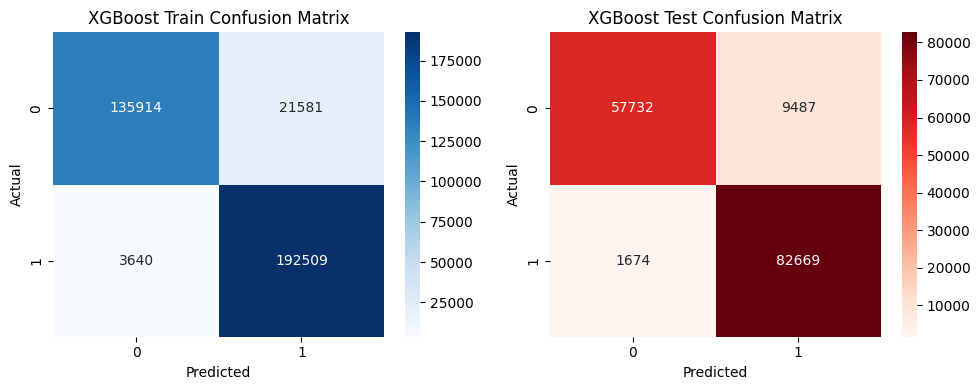

In [ ]:
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

cm_train = confusion_matrix(y_train, train_pred_xgb)
sns.heatmap(cm_train, annot=True, cmap='Blues', ax=ax[0], fmt='d')
ax[0].set_title('XGBoost Train Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')


cm_test = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_test, annot=True, cmap='Reds', ax=ax[1], fmt='d')
ax[1].set_title('XGBoost Test Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()


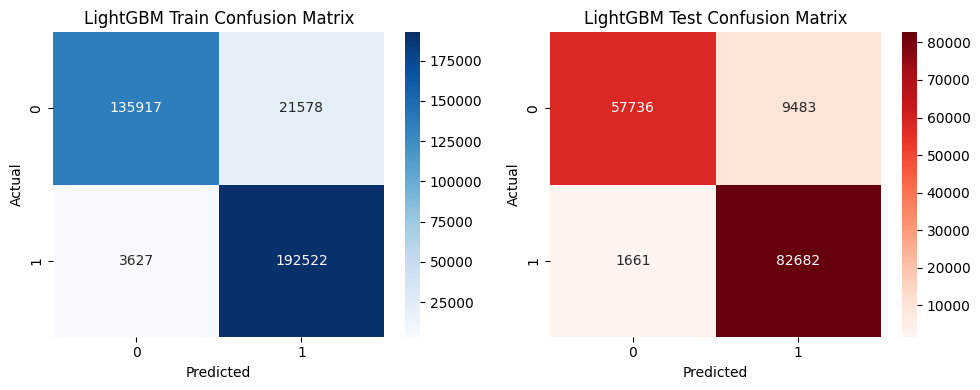

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

cm_train = confusion_matrix(y_train, train_pred_lgbm)
sns.heatmap(cm_train, annot=True, cmap='Blues', ax=ax[0], fmt='d')
ax[0].set_title('LightGBM Train Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

cm_test = confusion_matrix(y_test, lgbm_pred)
sns.heatmap(cm_test, annot=True, cmap='Reds', ax=ax[1], fmt='d')
ax[1].set_title('LightGBM Test Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()

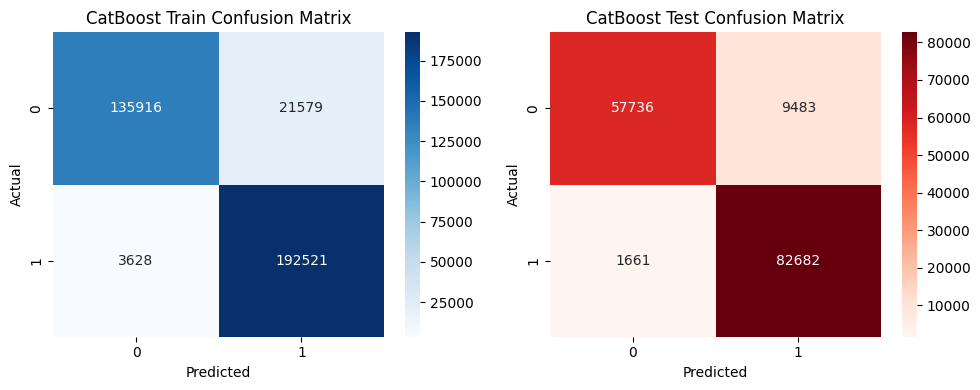

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

cm_train = confusion_matrix(y_train, train_pred_cat)
sns.heatmap(cm_train, annot=True, cmap='Blues', ax=ax[0], fmt='d')
ax[0].set_title('CatBoost Train Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')


cm_test = confusion_matrix(y_test, cat_pred)
sns.heatmap(cm_test, annot=True, cmap='Reds', ax=ax[1], fmt='d')
ax[1].set_title('CatBoost Test Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()

the confusion matrix shows the results of the three models between training and testing dataset, LighGBM is has more correct prediction on people who churned on the training dataset compared to other models, but both CatBoost and LightGBM are the most accurate when it comes in predicting customers who did not churned. on the other hand, LightGBM still is the more accurate in predicting churned customers in training dataset, and again both CatBoost and LightGBM has the same counts of correct predicted churned customers

In [ ]:
# making a classification report on the 3 models

from sklearn.metrics import classification_report

print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

print("\nLightGBM Classification Report:")
print(classification_report(y_test, lgbm_pred))

print("\nCatBoost Classification Report:")
print(classification_report(y_test, cat_pred))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91     67219
           1       0.90      0.98      0.94     84343

    accuracy                           0.93    151562
   macro avg       0.93      0.92      0.92    151562
weighted avg       0.93      0.93      0.93    151562


LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91     67219
           1       0.90      0.98      0.94     84343

    accuracy                           0.93    151562
   macro avg       0.93      0.92      0.92    151562
weighted avg       0.93      0.93      0.93    151562


CatBoost Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91     67219
           1       0.90      0.98      0.94     84343

    accuracy                           0.93    151562
   macro avg       0.93      0.

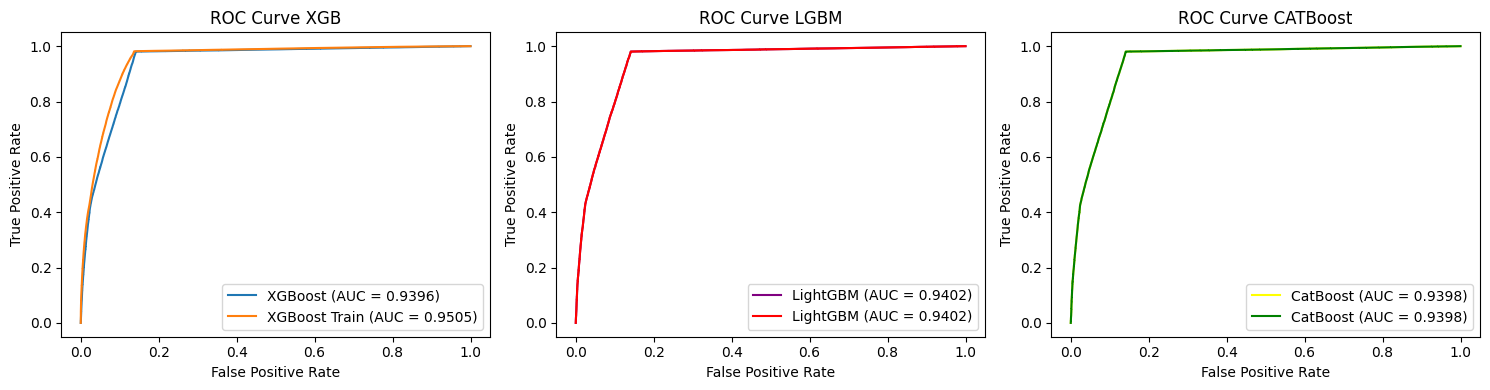

In [ ]:
# plotting the roc auc curve of the 3 models

from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
fpr_xgb_train, tpr_xgb_train, _ = roc_curve(y_train, xgb_model.predict_proba(X_train)[:, 1])
roc_auc_xgb_train = auc(fpr_xgb_train, tpr_xgb_train)
ax[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {round(roc_auc_xgb,4)})')
ax[0].plot(fpr_xgb_train, tpr_xgb_train, label=f'XGBoost Train (AUC = {round(roc_auc_xgb_train,4)})')
ax[0].set_title('ROC Curve XGB')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()

fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, lgbm_model.predict_proba(X_test)[:, 1])
roc_auc_lgbm = auc(fpr_lgbm, tpr_lgbm)
fpr_lgbm_train, tpr_lgbm_train, _ = roc_curve(y_train, lgbm_model.predict_proba(X_train)[:, 1])
roc_auc_lgbm_train = auc(fpr_lgbm_train, tpr_lgbm_train)
ax[1].plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {round(roc_auc_lgbm,4)})',color='purple')
ax[1].plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {round(roc_auc_lgbm,4)})', color='red')
ax[1].set_title('ROC Curve LGBM')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend()


fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_model.predict_proba(X_test)[:, 1])
roc_auc_cat = auc(fpr_cat, tpr_cat)
fpr_cat_train, tpr_cat_train, _ = roc_curve(y_train, cat_model.predict_proba(X_train)[:, 1])
roc_auc_cat_train = auc(fpr_cat_train, tpr_cat_train)
ax[2].plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {round(roc_auc_cat,4)})', color='yellow')
ax[2].plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {round(roc_auc_cat,4)})', color='green')
ax[2].set_title('ROC Curve CATBoost')
ax[2].set_xlabel('False Positive Rate')
ax[2].set_ylabel('True Positive Rate')
ax[2].legend()

plt.tight_layout()

Three gradient boosting models were trained and evaluated
to predict customer churn: XGBoost, LightGBM, and CatBoost.
All three models were tuned using Optuna with 5-Fold
Stratified Cross Validation.
</br></br>
Results show that LightGBM the highest
test accuracy, with CatBoost showing the smallest gap between
training and testing accuracy it indicates it is the most
stable and generalizable model among the three.
</br></br>
All three models showed no significant signs of overfitting,
as the difference between training and testing accuracy
remained close across all models.

## Saving the model


In [ ]:
import joblib
import os
os.makedirs('/content/drive/MyDrive/projects/models/churnproject', exist_ok=True)

joblib.dump(xgb_model,  '/content/drive/MyDrive/projects/models/churnproject/xgboost_model.pkl')
joblib.dump(lgbm_model, '/content/drive/MyDrive/projects/models/churnproject/lightgbm_model.pkl')
joblib.dump(cat_model,  '/content/drive/MyDrive/projects/models/churnproject/catboost_model.pkl')

print("All models saved")

All models saved
